Link dataset: https://huggingface.co/datasets/taesiri/imagenet-hard

In [2]:
from datasets import load_from_disk

ds = load_from_disk("../data/imagenet-hard")

images = ds["validation"]["image"]
labels = ds["validation"]["label"]

# DATA OVERVIEW

In [3]:
from collections import Counter
import numpy as np
from PIL import Image
from tqdm import tqdm

sizes = []
ratios = []
modes = Counter()
bad_images = 0

for img in tqdm(images):
    try:
        if not isinstance(img, Image.Image):
            bad_images += 1
            continue

        w, h = img.size
        sizes.append((w, h))
        ratios.append(w / h)

        modes[img.mode] += 1

    except Exception:
        bad_images += 1

print("Total images:", len(images))
print("Bad images:", bad_images)
print("Unique modes:", modes)

100%|██████████| 10980/10980 [02:42<00:00, 67.56it/s] 

Total images: 10980
Bad images: 0
Unique modes: Counter({'RGB': 9148, 'RGBA': 1268, 'L': 562, 'CMYK': 2})


In [4]:
widths = [w for w, h in sizes]
heights = [h for w, h in sizes]

print("Width range:", min(widths), "→", max(widths))
print("Height range:", min(heights), "→", max(heights))

print("Mean size:", np.mean(widths), np.mean(heights))

Width range: 70 → 6586
Height range: 56 → 5089
Mean size: 647.9906193078324 724.6224043715847


In [5]:
ratios = np.array(ratios)

print("Aspect ratio stats:")
print("min:", ratios.min())
print("max:", ratios.max())
print("mean:", ratios.mean())

Aspect ratio stats:
min: 0.16863406408094436
max: 3.863013698630137
mean: 1.0828678927901103


Size: (1072, 331)


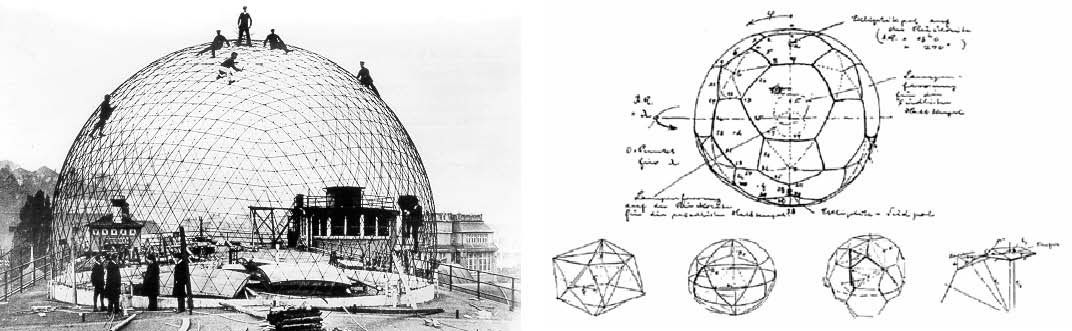

Size: (390, 120)


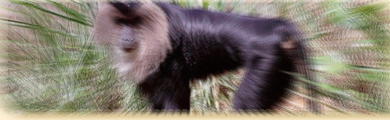

Size: (850, 261)


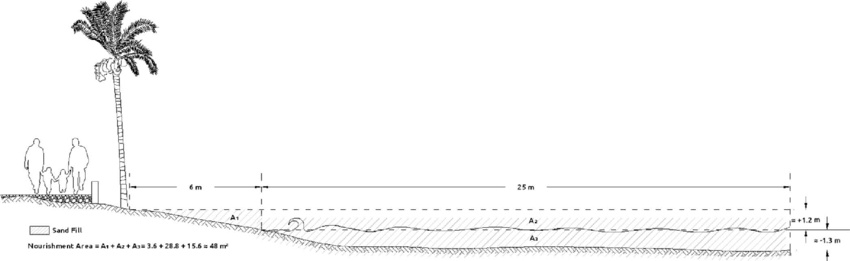

Size: (850, 261)


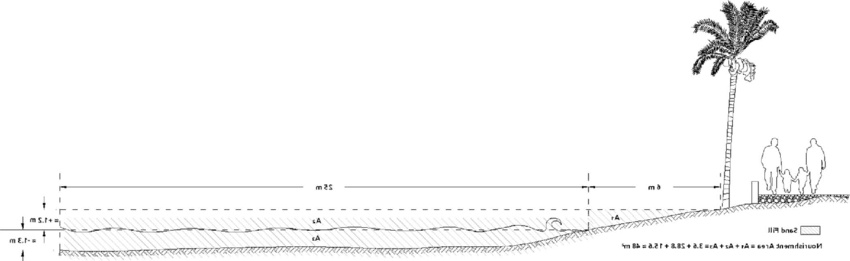

Size: (564, 146)


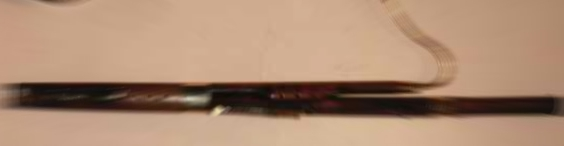

In [6]:
extreme = np.argsort(np.abs(ratios - 1))[-5:]

for i in extreme:
    img = images[i]
    print("Size:", img.size)
    display(img)